### Phase 2 - Step 1: Environment Setup & Data Pipeline Tools
This step imports all necessary libraries, defines parameters, and constructs the classes and functions required for robust DataLoading. We handle loading the arrays from pickles and properly splitting them into Train/Val/Test subsets.

In [2]:
import os
import copy
from pathlib import Path
from typing import Literal, Tuple, Optional, List, Dict, Iterable

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_curve, auc, 
                             precision_recall_curve, average_precision_score)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# --------------------------------------------------------------------------- #
# Core Configurations
# --------------------------------------------------------------------------- #
WALLS_PKL = Path("wall_data.pkl")
DECKS_PKL = Path("deck_data.pkl")
LABEL_MAP = {"Non-Cracked": 0, "Cracked": 1}

# Create a checkpoint directory to hold the three separate models
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

# --------------------------------------------------------------------------- #
# Data Loaders & Splitting definitions
# --------------------------------------------------------------------------- #
def load_dataframe(domain: Literal["walls", "decks", "both"] = "both") -> pd.DataFrame:
    dfs = []
    if domain in ("walls", "both"):       dfs.append(pd.read_pickle(WALLS_PKL))
    if domain in ("decks", "both"):       dfs.append(pd.read_pickle(DECKS_PKL))
    if not dfs: raise ValueError("No dataframes loaded.")
    
    df = pd.concat(dfs, axis=0, ignore_index=True)
    df["Label"] = df["Label"].map(LABEL_MAP)
    return df

def stratified_splits(df: pd.DataFrame, train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):
    train_df, temp_df = train_test_split(df, train_size=train_size, stratify=df["Label"], random_state=random_state, shuffle=True)
    val_fraction = val_size / (val_size + test_size)
    val_df, test_df = train_test_split(temp_df, train_size=val_fraction, stratify=temp_df["Label"], random_state=random_state, shuffle=True)
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

class CrackDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform: Optional[transforms.Compose] = None):
        self.df = df
        self.transform = transform

    def __len__(self) -> int: return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img_np = row["ImageData"]
        if img_np.dtype != np.uint8: img_np = img_np.astype(np.uint8)
        img_pil = Image.fromarray(img_np)
        label = int(row["Label"])
        return self.transform(img_pil) if self.transform else transforms.ToTensor()(img_pil), label

# Transforms
imagenet_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform = transforms.Compose([transforms.RandomHorizontalFlip(p=0.5), transforms.RandomVerticalFlip(p=0.5), transforms.ToTensor(), imagenet_norm])
eval_transform = transforms.Compose([transforms.ToTensor(), imagenet_norm])

def build_dataloaders(domain: Literal["walls", "decks", "both"] = "both", batch_size: int = 32, num_workers: int = 0):
    df = load_dataframe(domain=domain)
    train_df, val_df, test_df = stratified_splits(df)
    train_dl = DataLoader(CrackDataset(train_df, train_transform), batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_dl = DataLoader(CrackDataset(val_df, eval_transform), batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_dl = DataLoader(CrackDataset(test_df, eval_transform), batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_dl, val_dl, test_dl


### Phase 2 - Step 2: Model Architecture Engine
Generates Transfer Learning Models (ResNet50 / VGG16). Critically, it accurately locks the shallow feature parameters, reducing computation while preventing pre-trained catastrophic forgetting.

In [3]:
def build_model(model_name: str = "resnet50", freeze_early: bool = True, out_features: int = 1) -> nn.Module:
    """
    Build a transfer learning model and replace the final head for binary classification.
    """
    model_name = model_name.lower()
    if model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_feats = model.fc.in_features
        model.fc = nn.Linear(in_feats, out_features)
        
        # Safely freeze early feature extractors
        if freeze_early:
            for block in [model.conv1, model.bn1, model.layer1]:
                for param in block.parameters():
                    param.requires_grad = False
                    
    elif model_name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        in_feats = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_feats, out_features)
        
        if freeze_early:
            for layer in list(model.features.children())[:10]:
                for param in layer.parameters():
                    param.requires_grad = False
    else:
        raise ValueError("Unsupported model; choose 'resnet50' or 'vgg16'.")

    return model


### Phase 2 - Step 3: Refactored Robust Training Loop 
Reintroduces the Pos_weight capability for class imbalance handling and retains our comprehensive Early Stopping and Metric tracking mechanisms.

In [4]:
def train_model_pipeline(
    model: nn.Module, 
    train_loader: DataLoader, 
    val_loader: DataLoader, 
    device: torch.device,
    save_path: str,
    epochs: int = 50, 
    lr: float = 1e-4, 
    patience: int = 6,
    pos_weight_val: Optional[float] = None
) -> Dict:
    """
    Unified training engine integrated with Learning Rate Scheduler and Early Stopping.
    """
    model = model.to(device)
    
    # Restored: Support for Class Imbalance Penalty
    if pos_weight_val is not None:
        pos_weight = torch.tensor([pos_weight_val]).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()
    
    # Only pass active parameters to Optimizer
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=lr)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = []
    
    print(f"--- Training Sequence Initiated. Output: {save_path} ---")

    for epoch in range(1, epochs + 1):
        # ------------------ Training Phase ------------------
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            
        train_loss /= len(train_loader.dataset)
        
        # ------------------ Validation Phase ------------------
        model.eval()
        val_loss = 0.0
        all_targets, all_preds = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)

                logits = model(images)
                loss = criterion(logits, labels)
                val_loss += loss.item() * images.size(0)

                probs = torch.sigmoid(logits).squeeze(1)
                preds = (probs >= 0.5).long()
                all_targets.extend(labels.squeeze(1).cpu().numpy().tolist())
                all_preds.extend(preds.cpu().numpy().tolist())

        val_loss /= len(val_loader.dataset)
        rec = recall_score(all_targets, all_preds, zero_division=0)
        
        history.append({"epoch": epoch, "val_loss": val_loss})
        scheduler.step(val_loss)
        
        # Save mechanism
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            status_flag = "[✓ BEST SAVED]"
        else:
            epochs_no_improve += 1
            status_flag = f"[! NO IMP: {epochs_no_improve}/{patience}]"
            
        print(f"Epoch {epoch:03d}/{epochs} | T-Loss: {train_loss:.4f} | V-Loss: {val_loss:.4f} | V-Rec: {rec:.4f} {status_flag}")

        # Early Stopping Execute
        if epochs_no_improve >= patience:
            print(f"====== Early Stopping Triggered at Epoch {epoch} ! ======")
            break

    # Restore ultimate weights automatically before function end
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    return history


### Phase 2 - Step 4: Multi-Domain Automated Training & Caching Sequence
In this loop, execution strictly filters datasets and handles checkpoint caching securely. If a .pth model file already exists for a domain, it cleanly skips the extensive epoch iterations to save computational resource while loading dataloaders for the inference phase.

In [5]:
# Hardware Config
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Hardware Compute Engine initialized onto: {device}\n")

domains_to_train = ["walls", "decks", "both"]
pipelines_artifacts = {}

for domain in domains_to_train:
    print(f"\n============================================================")
    print(f" PROCESSING PIPELINE FOR DOMAIN: {domain.upper()}")
    print(f"============================================================")
    
    param_path = CHECKPOINT_DIR / f"v3_best_model_{domain}.pth"
    train_dl, val_dl, test_dl = build_dataloaders(domain=domain, batch_size=32)
    
    model = build_model(model_name="resnet50", freeze_early=True).to(device)
    
    # Restored Logic: OS Path checking to bypass hours of redundant training
    if os.path.exists(param_path):
        print(f" Info: Detected existing pretrained artifact `{param_path.name}`.")
        print('Skipping extensive Epoch loop and securing pre-trained knowledge base...')
        
    else:
        print('Initiating Deep Training sequences...')
        train_model_pipeline(
            model=model, 
            train_loader=train_dl, 
            val_loader=val_dl, 
            device=device,
            save_path=str(param_path),
            epochs=50,       
            patience=6,
            lr=1e-4,
            pos_weight_val=None  # Adjust to float (e.g. 1.5) if specific domain False Negatives are excessively high
        )
    
    # Persist the necessary configurations to dictionary logic
    pipelines_artifacts[domain] = {
        "model_path": str(param_path),
        "test_dl": test_dl
    }


Hardware Compute Engine initialized onto: cuda


 PROCESSING PIPELINE FOR DOMAIN: WALLS
 Info: Detected existing pretrained artifact `v3_best_model_walls.pth`.
Skipping extensive Epoch loop and securing pre-trained knowledge base...

 PROCESSING PIPELINE FOR DOMAIN: DECKS
 Info: Detected existing pretrained artifact `v3_best_model_decks.pth`.
Skipping extensive Epoch loop and securing pre-trained knowledge base...

 PROCESSING PIPELINE FOR DOMAIN: BOTH
 Info: Detected existing pretrained artifact `v3_best_model_both.pth`.
Skipping extensive Epoch loop and securing pre-trained knowledge base...


### Phase 2 - Step 5: Independent Evaluation Suite & Enhanced Visualizations
Calculates extensive analytical metrics. Upgraded to generate a comprehensive 2x2 subplot matrix featuring Both Raw Tracking (Absolute counts) and Normalized Tracking (Percentages), alongside standard ROC AUC and critically crucial Precision-Recall (PR) Curves for heavily imbalanced defect detection thresholds.

In [6]:
def load_and_evaluate(pretrained_model_path: str, test_dataloader, device: torch.device):
    """
    Evaluates dataset on test_dataloader using pre-trained path strings securely.
    """
    eval_model = build_model("resnet50", freeze_early=True).to(device)
    eval_model.load_state_dict(torch.load(pretrained_model_path, map_location=device, weights_only=True))
    eval_model.eval()
    
    targets, probs = [], []
    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(device)
            logits = eval_model(images)
            p = torch.sigmoid(logits).squeeze(1)
            targets.extend(labels.cpu().numpy().tolist())
            probs.extend(p.cpu().numpy().tolist())
            
    return np.array(targets), np.array(probs)

def plot_comprehensive_analytics(targets: np.ndarray, probs: np.ndarray, preds: np.ndarray, domain_name: str):
    """
    Generates a 4-panel dashboard containing absolute counts, error distributions, and diagnostic curves.
    """
    # 1. Matrices Pre-calculation
    cm_raw = confusion_matrix(targets, preds)
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True).clip(min=1e-9)
    
    # 2. Curves Pre-calculation
    fpr, tpr, _ = roc_curve(targets, probs)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(targets, probs)
    pr_auc = average_precision_score(targets, probs)
    
    # 3. Figure Initialization (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    ax1, ax2, ax3, ax4 = axes.flatten()
    
    # --- Top-Left: Raw Confusion Matrix ---
    sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues", ax=ax1,
                xticklabels=['Non-Cracked', 'Cracked'], yticklabels=['Non-Cracked', 'Cracked'])
    ax1.set_title(f"[{domain_name.upper()}] Raw Confusion Matrix")
    ax1.set_xlabel("AI Predicted (Count)")
    ax1.set_ylabel("True Annotations (Count)")
    
    # --- Top-Right: Normalized Confusion Matrix ---
    sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Reds", ax=ax2,
                xticklabels=['Non-Cracked', 'Cracked'], yticklabels=['Non-Cracked', 'Cracked'])
    ax2.set_title(f"[{domain_name.upper()}] Normalized Error Matrix")
    ax2.set_xlabel("AI Predicted (%)")
    ax2.set_ylabel("True Annotations (%)")
    
    # --- Bottom-Left: ROC Curve ---
    ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax3.set_xlim([0.0, 1.0])
    ax3.set_ylim([0.0, 1.05])
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate (Recall)')
    ax3.set_title('ROC Curve')
    ax3.legend(loc="lower right")
    ax3.grid(alpha=0.3)
    
    # --- Bottom-Right: Precision-Recall Curve ---
    ax4.plot(recall, precision, color='purple', lw=2, label=f'Avg Precision = {pr_auc:.3f}')
    ax4.set_xlim([0.0, 1.0])
    ax4.set_ylim([0.0, 1.05])
    ax4.set_xlabel('Recall (Sensitivity)')
    ax4.set_ylabel('Precision')
    ax4.set_title('Precision-Recall (PR) Curve')
    ax4.legend(loc="lower left")
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


### Phase 2 - Step 6: Multi-Model Inference Reporting Hub
Initiates our extreme structural safety thresholds constraints and executes quantitative + visual rendering for our 3 unique AI models across respective test datasets.

INITIATING FINAL PHASE CROSS-DOMAIN CHECK SUMMARY:

COMPREHENSIVE PERFORMANCE REPORT: WALLS DATASET
Text-based Quality Metrics Extraction:
              precision    recall  f1-score   support

 Non-Cracked     0.9646    0.8713    0.9156      2129
     Cracked     0.6432    0.8790    0.7429       562

    accuracy                         0.8729      2691
   macro avg     0.8039    0.8752    0.8292      2691
weighted avg     0.8975    0.8729    0.8795      2691



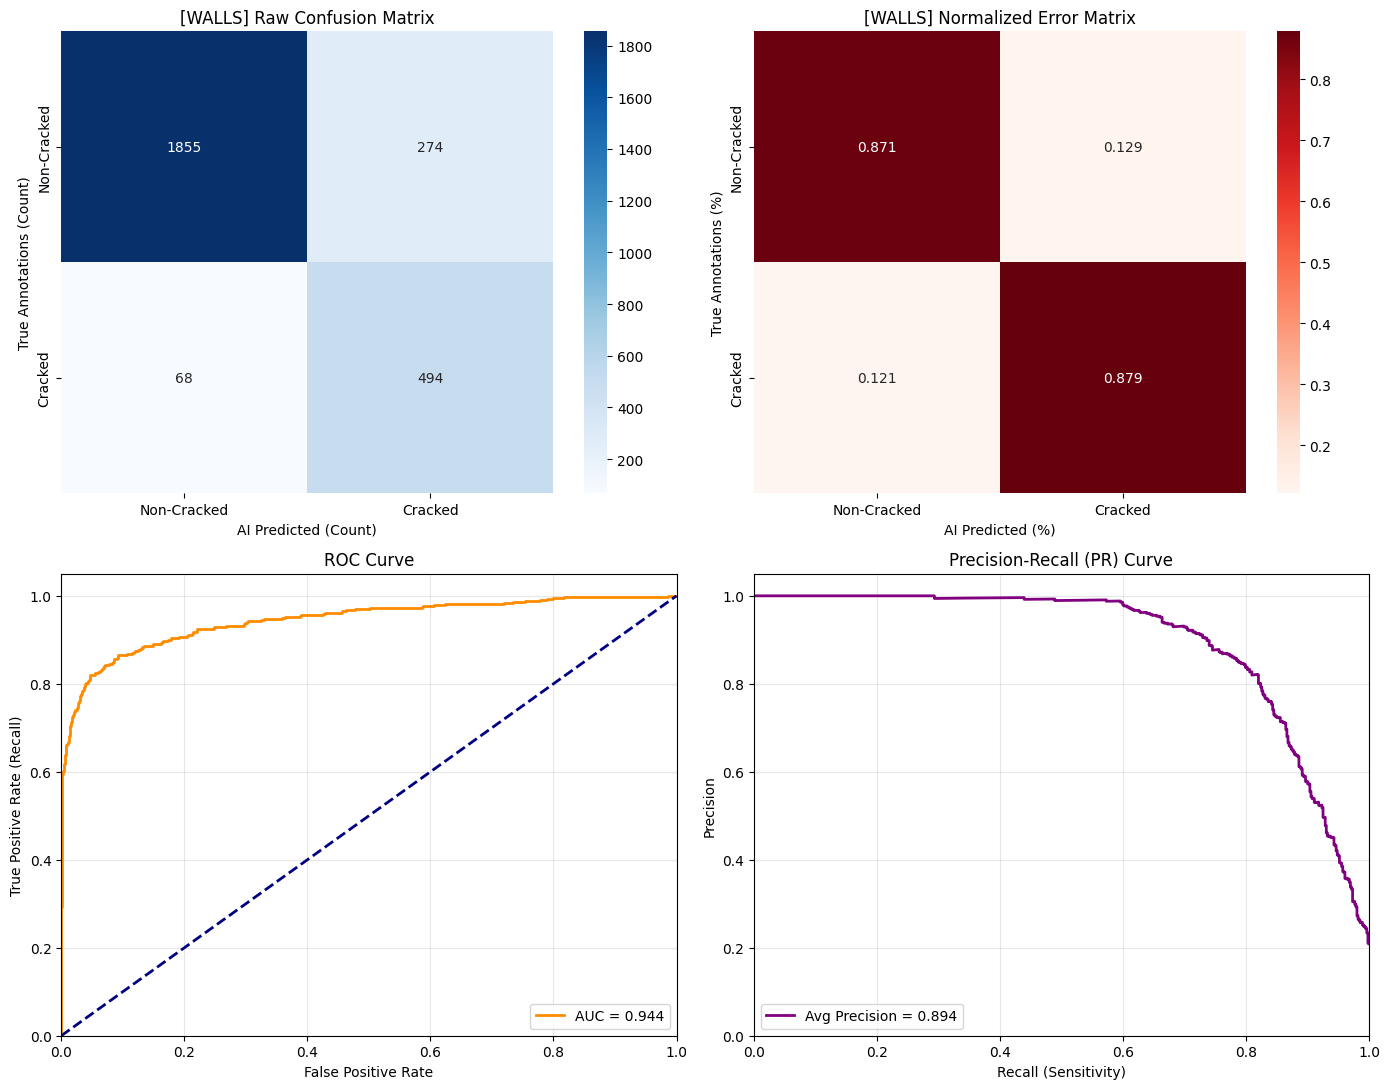


COMPREHENSIVE PERFORMANCE REPORT: DECKS DATASET
Text-based Quality Metrics Extraction:
              precision    recall  f1-score   support

 Non-Cracked     0.9588    0.8638    0.9088      1725
     Cracked     0.4891    0.7785    0.6008       289

    accuracy                         0.8515      2014
   macro avg     0.7240    0.8212    0.7548      2014
weighted avg     0.8914    0.8515    0.8646      2014



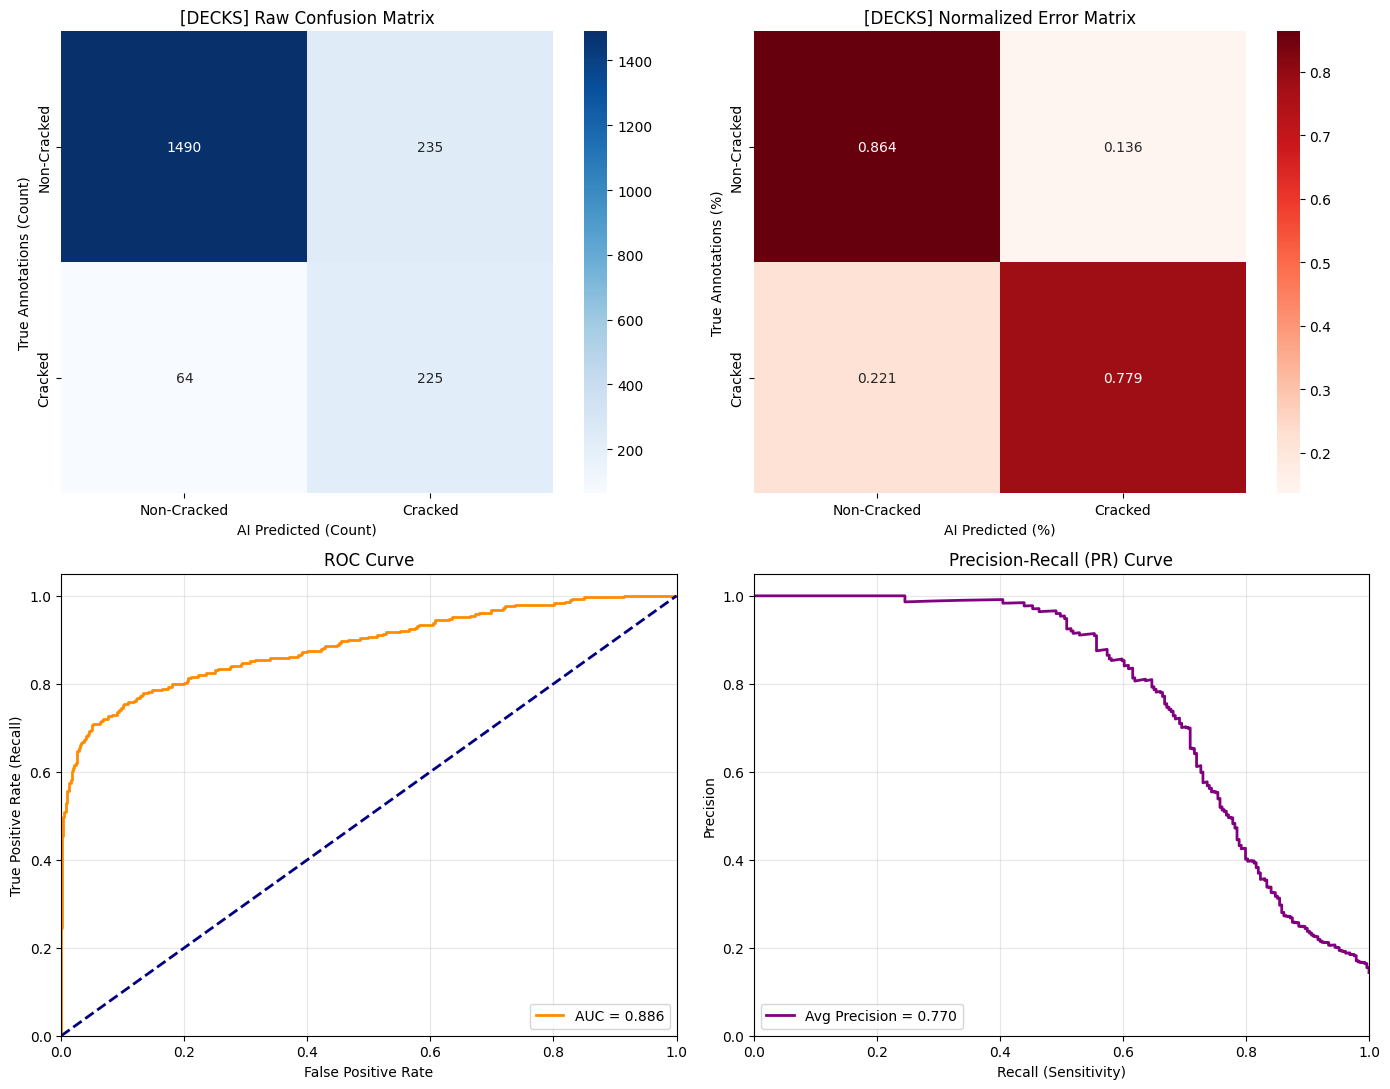


COMPREHENSIVE PERFORMANCE REPORT: BOTH DATASET
Text-based Quality Metrics Extraction:
              precision    recall  f1-score   support

 Non-Cracked     0.9525    0.9258    0.9389      3853
     Cracked     0.7021    0.7911    0.7439       852

    accuracy                         0.9014      4705
   macro avg     0.8273    0.8584    0.8414      4705
weighted avg     0.9071    0.9014    0.9036      4705



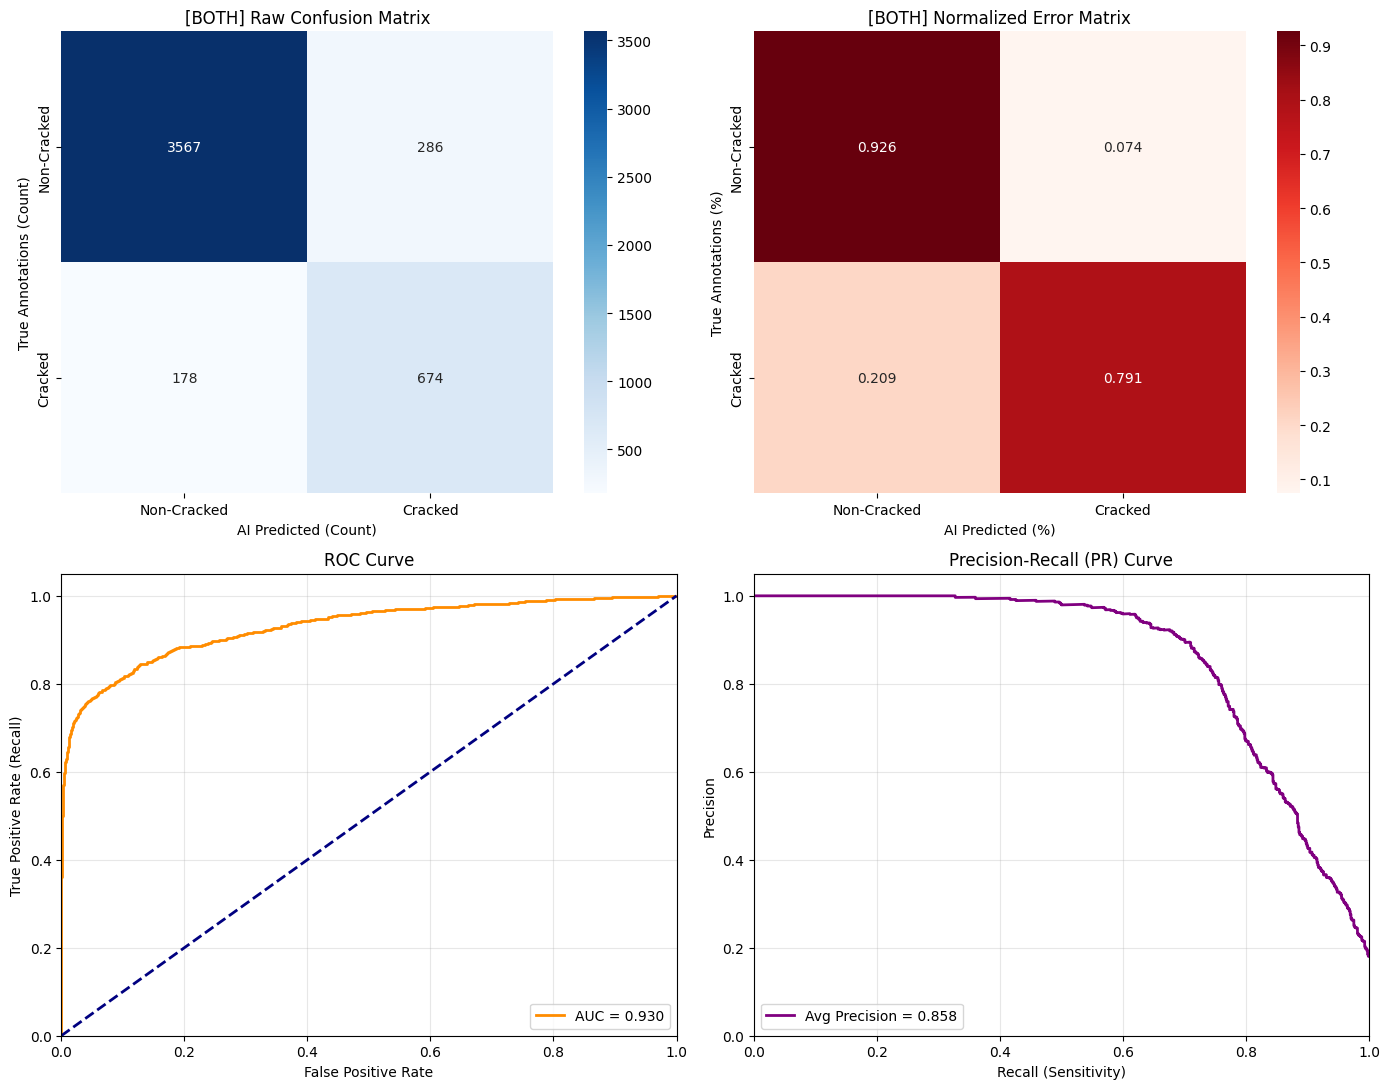

In [7]:
# Custom Threshold mapping for Safety Criteria
# Instead of default 0.50, any presence indicator slightly above 0.15 warns the engineer
CRITICAL_THRESHOLD = 0.15  

print("INITIATING FINAL PHASE CROSS-DOMAIN CHECK SUMMARY:")

for domain, configs in pipelines_artifacts.items():
    print(f"\n" + "="*65)
    print(f"COMPREHENSIVE PERFORMANCE REPORT: {domain.upper()} DATASET")
    print("="*65)
    
    # Extract robust probability distributions
    np_targets, np_probs = load_and_evaluate(configs["model_path"], configs["test_dl"], device)
    
    # Enforce strict safety thresholds 
    np_preds = (np_probs >= CRITICAL_THRESHOLD).astype(int)
    
    # 1. Print Standard Classification Report first
    print("Text-based Quality Metrics Extraction:")
    print(classification_report(np_targets, np_preds, target_names=['Non-Cracked', 'Cracked'], digits=4))
    
    # 2. Render highly detailed 2x2 graphics engine
    plot_comprehensive_analytics(np_targets, np_probs, np_preds, domain)


### Failure Analysis: Type 1 vs. Type 2 Errors

In the context of structural crack detection, not all errors are created equal. We categorize our model failures into two fundamental types:

* **Type 1 Error (False Positive - "Ghost Cracks")**: 
  * **Reality**: The surface is completely completely intact and safe.
  * **AI Prediction**: AI mistakenly claims there is a crack.
  * **Engineering Impact**: Minor. It leads to false alarms and wastes inspector time, but poses zero safety threat. AI is usually tricked by joints, shadows, or dirt.
  
* **Type 2 Error (False Negative - "Missed Anomalies")**: 
  * **Reality**: There is an actual structural fracture.
  * **AI Prediction**: AI misses it and confidently reports the surface is clean.
  * **Engineering Impact**: **SEVERE**. This is a critical safety blind spot. Failing to detect true structural damage can lead to sudden structural failures and hazards.

By extracting these exact failure cases, we can identify which specific textures or lighting conditions are deceiving our model.


[*] Scanning for erroneous classifications in Domain: WALLS...


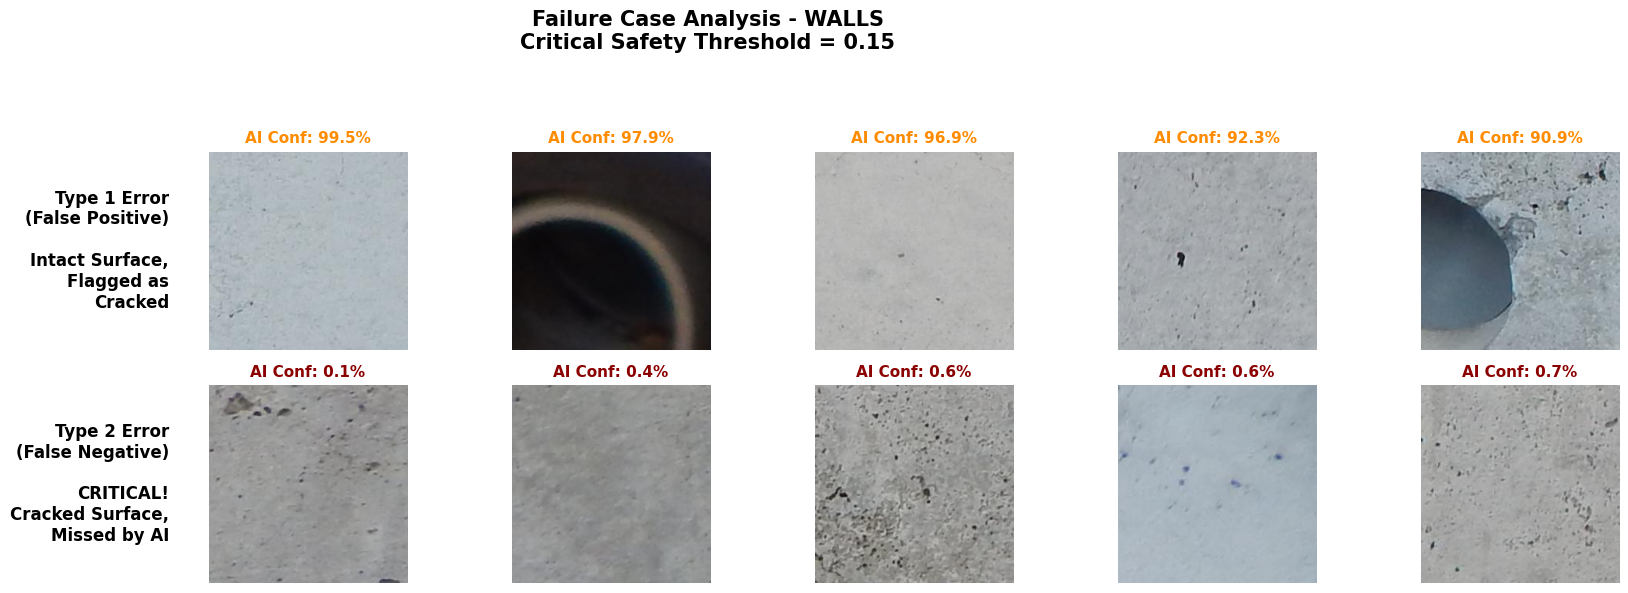


[*] Scanning for erroneous classifications in Domain: DECKS...


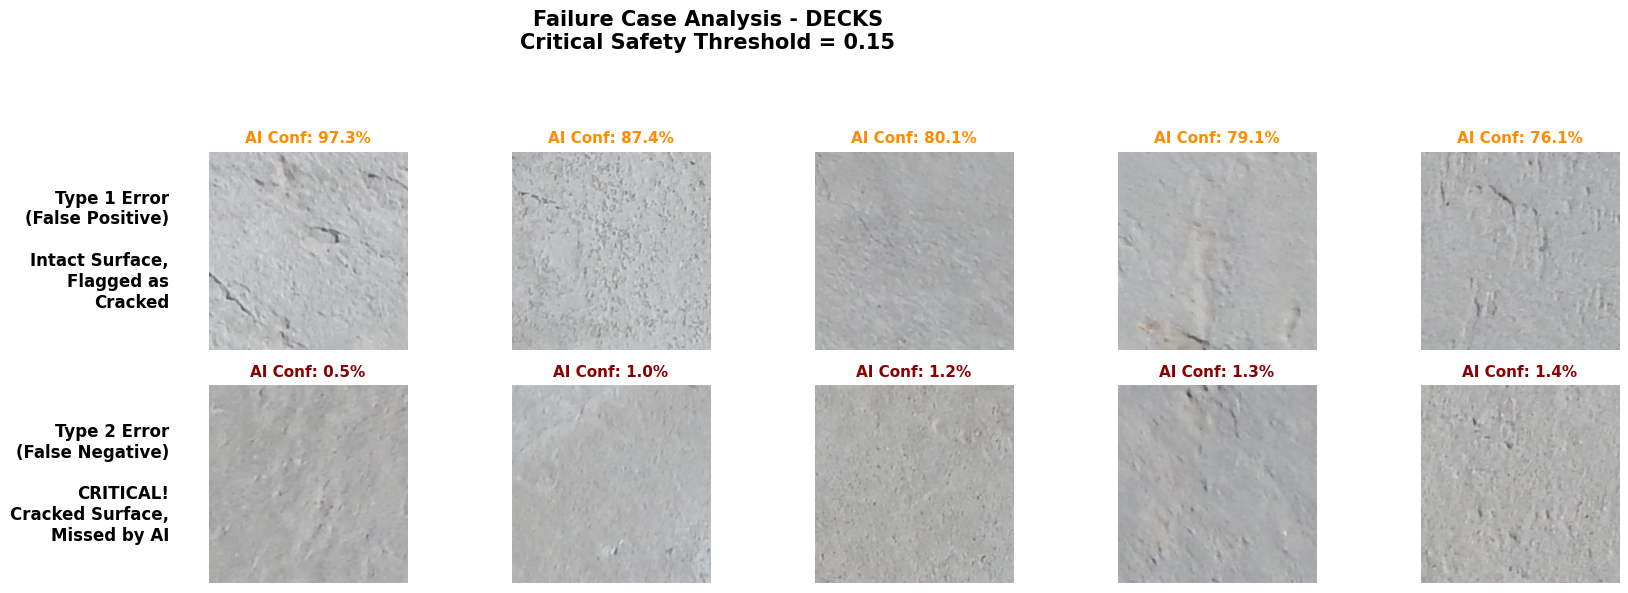


[*] Scanning for erroneous classifications in Domain: BOTH...


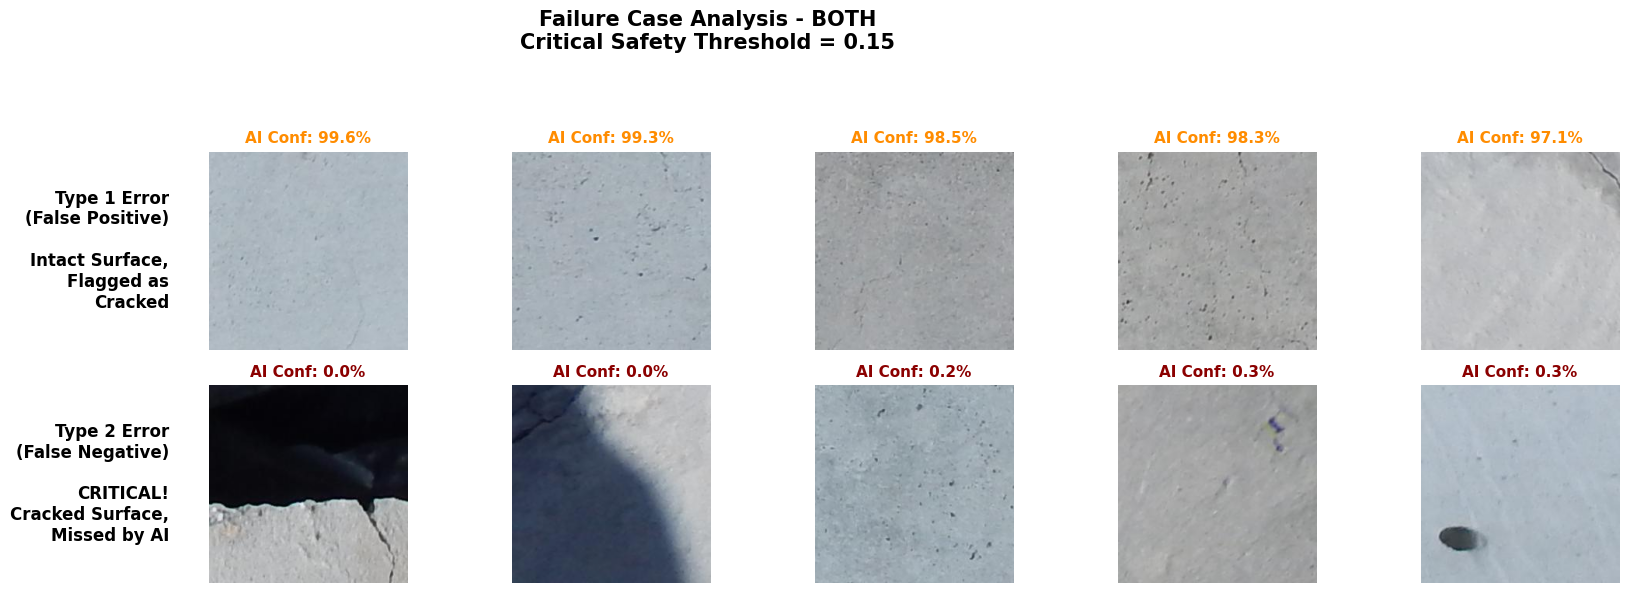

In [8]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import torchvision.transforms as transforms
import matplotlib.pyplot as plt

def extract_and_plot_errors(pretrained_model_path: str, test_dataloader, device: torch.device, domain_name: str, threshold: float = 0.15, num_samples: int = 5):

    eval_model = build_model("resnet50", freeze_early=True).to(device)
    eval_model.load_state_dict(torch.load(pretrained_model_path, map_location=device, weights_only=True))
    eval_model.eval()

    false_positives = []  
    false_negatives = []  

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)

    print(f"\n[*] Scanning for erroneous classifications in Domain: {domain_name.upper()}...")

    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(device)
            logits = eval_model(images)
            probs = torch.sigmoid(logits).squeeze(1)
            
            preds = (probs >= threshold).long()  
            labels = labels.to(device)
            
            for i in range(len(labels)):
                target = labels[i].item()
                pred = preds[i].item()
                prob = probs[i].item()

                if target == 0 and pred == 1:
                    img = (images[i] * std + mean).clamp(0, 1).cpu()  
                    false_positives.append((img, prob))
                elif target == 1 and pred == 0:
                    img = (images[i] * std + mean).clamp(0, 1).cpu()
                    false_negatives.append((img, prob))
                    
    false_positives.sort(key=lambda x: x[1], reverse=True)
    false_negatives.sort(key=lambda x: x[1], reverse=False)

    def plot_row(samples, title, ax_row):
        for i, ax in enumerate(ax_row):
            if i < len(samples):
                img, prob = samples[i]
                img_np = img.permute(1, 2, 0).numpy()  
                ax.imshow(img_np)
                ax.set_title(f"AI Conf: {prob*100:.1f}%", color="darkred" if "False Negative" in title else "darkorange", fontsize=11, fontweight='bold')
            ax.axis('off')
        
        ax_row[0].text(-0.2, 0.5, title, transform=ax_row[0].transAxes, 
                       fontsize=12, fontweight='bold', va='center', ha='right', rotation=0)

    actual_samples = min(num_samples, max(len(false_positives), len(false_negatives)))
    if actual_samples == 0:
        print(" -> No errors found at this threshold!")
        return

    fig, axes = plt.subplots(2, actual_samples, figsize=(4 * actual_samples, 6))
    fig.suptitle(f"Failure Case Analysis - {domain_name.upper()}\nCritical Safety Threshold = {threshold}", fontsize=15, fontweight='bold')


    plot_row(false_positives[:actual_samples], f"Type 1 Error\n(False Positive)\n\nIntact Surface,\nFlagged as\nCracked", axes[0] if actual_samples > 1 else axes[0])
    plot_row(false_negatives[:actual_samples], f"Type 2 Error\n(False Negative)\n\nCRITICAL!\nCracked Surface,\nMissed by AI", axes[1] if actual_samples > 1 else axes[1])

    plt.tight_layout(rect=[0.12, 0, 1, 0.9]) 
    plt.show()


for domain, configs in pipelines_artifacts.items():
    extract_and_plot_errors(
        pretrained_model_path=configs["model_path"],
        test_dataloader=configs["test_dl"],
        device=device,
        domain_name=domain,
        threshold=CRITICAL_THRESHOLD,  
        num_samples=5 
    )


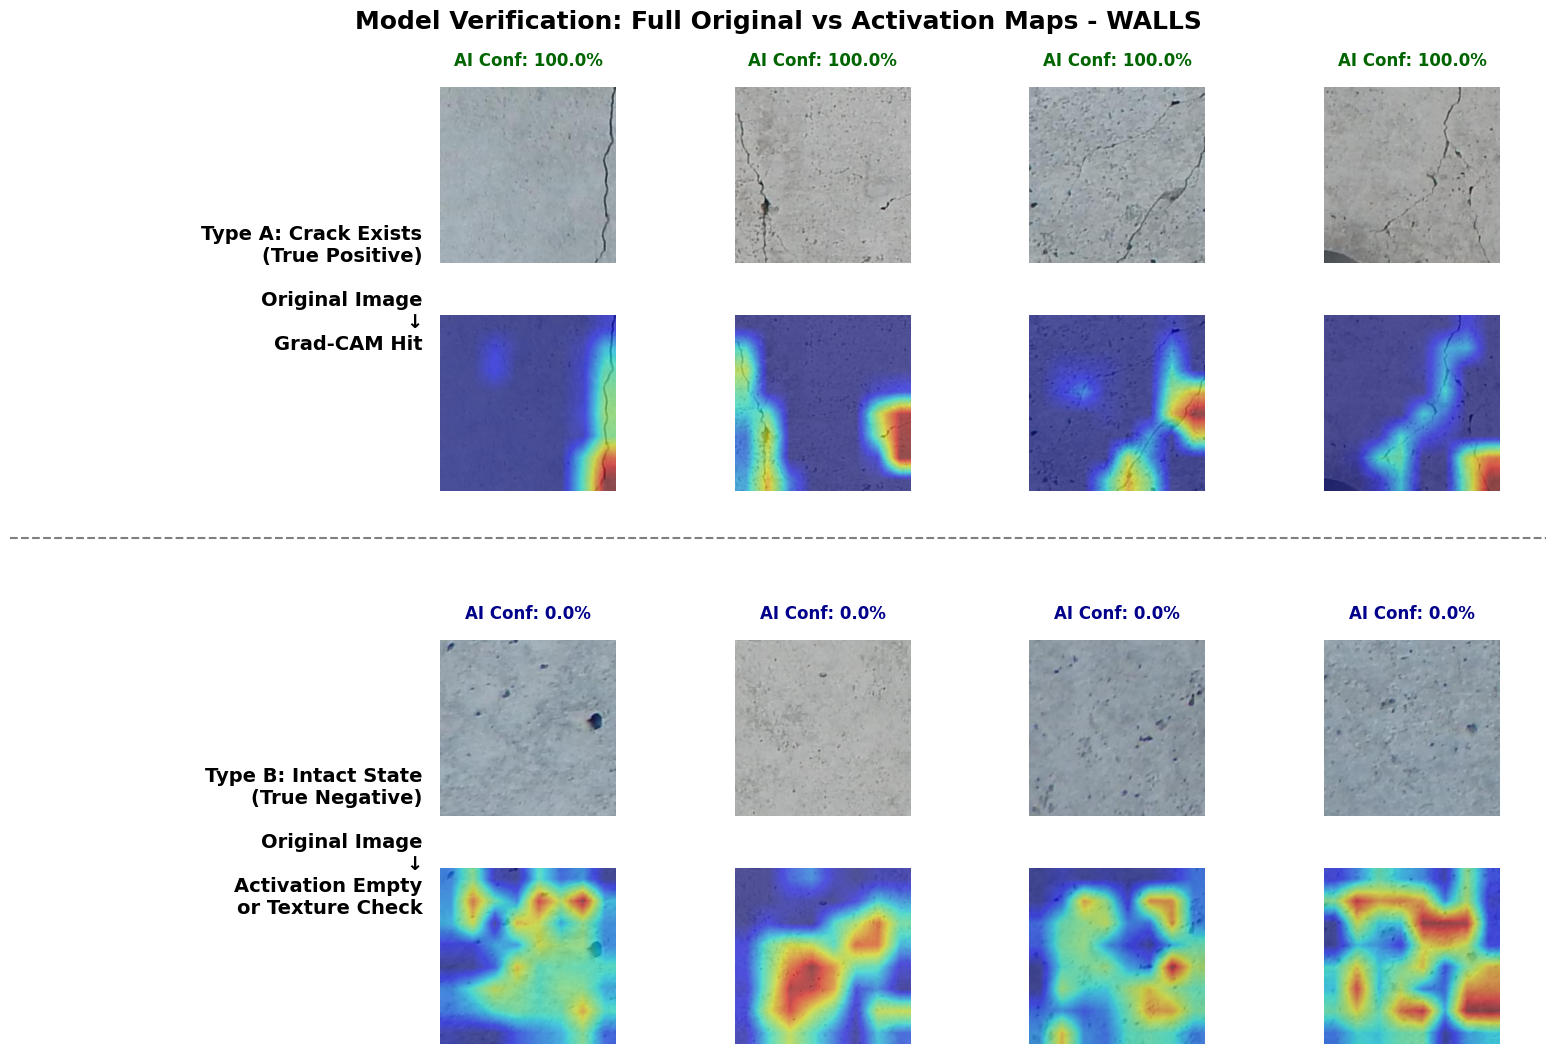

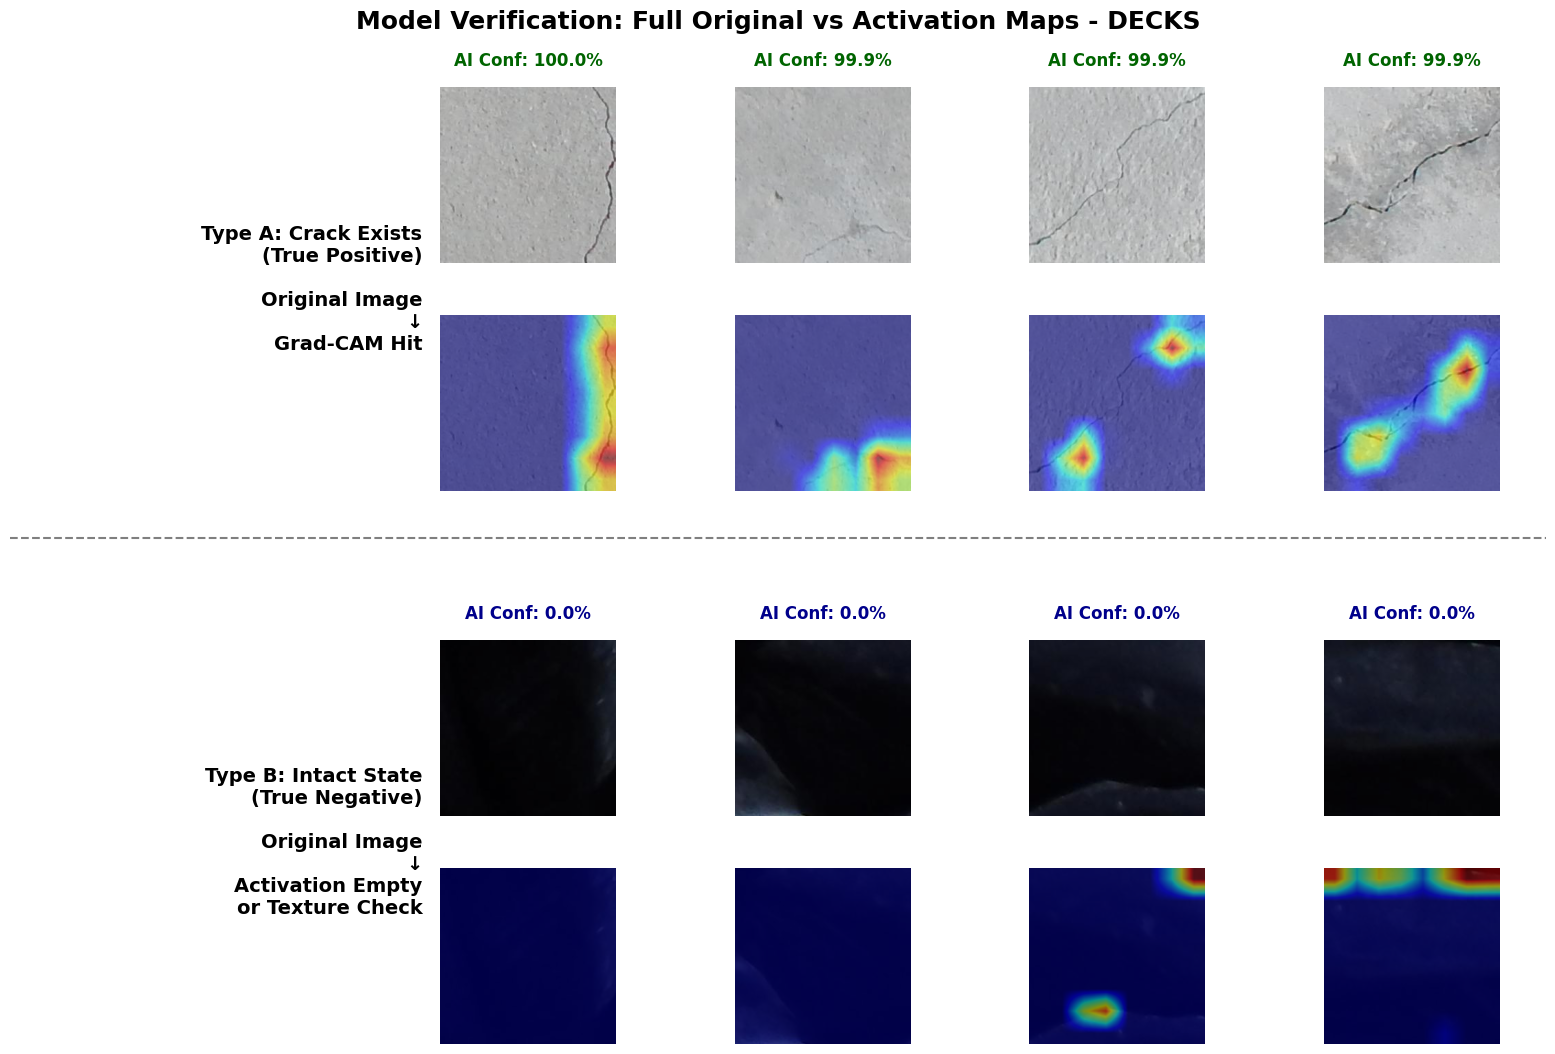

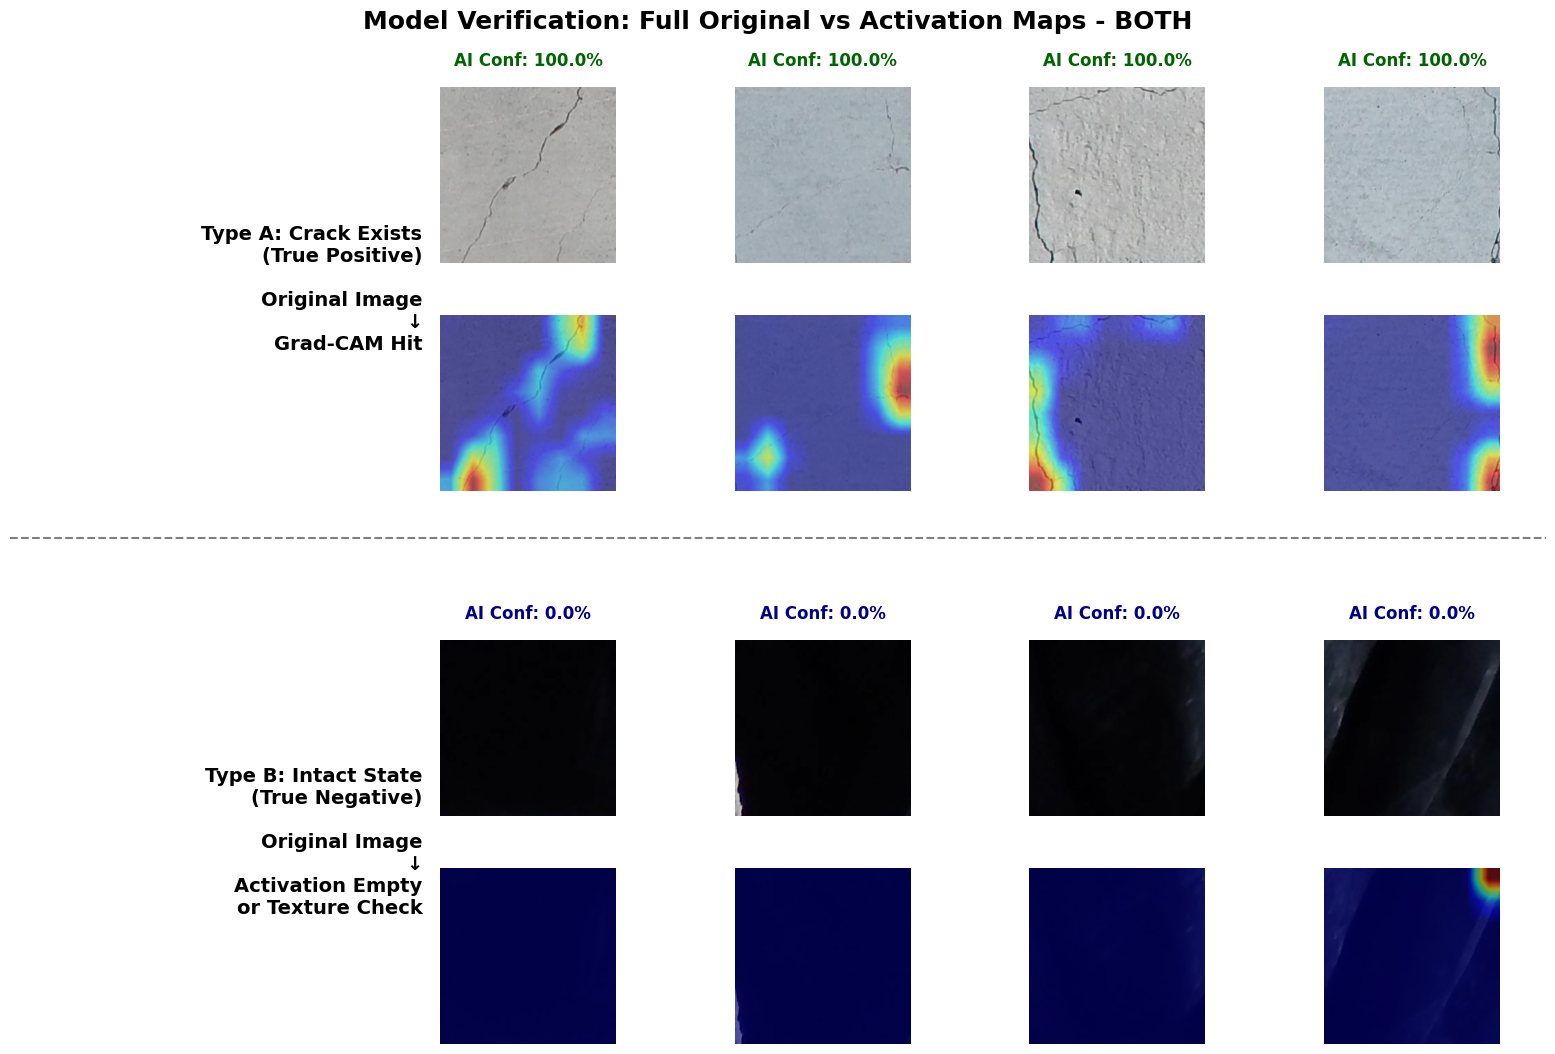

In [ ]:
import warnings
warnings.filterwarnings("ignore") 

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ==========================================
# Mode 1: Grad-CAM Core Interpreter 
# ==========================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.fwd_handle = self.target_layer.register_forward_hook(self._save_activations)

    def _save_activations(self, module, inp, out):
        self.activations = out

    def _save_activation_grads(self, grad):
        self.gradients = grad.detach()

    def __call__(self, x, class_idx):
        self.model.zero_grad(set_to_none=True)
        self.gradients, self.activations = None, None

        logits = self.model(x)
        if self.activations.requires_grad:
            self.activations.register_hook(self._save_activation_grads)

        if logits.ndim == 1:
            logits = logits.unsqueeze(0)

        score = logits[:, 0].sum() if class_idx == 1 else (-logits[:, 0]).sum()
        score.backward()

        activations = self.activations.detach()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam

    def close(self):
        self.fwd_handle.remove()

def find_last_conv_layer(model):
    return [m for m in model.modules() if isinstance(m, nn.Conv2d)][-1]

def apply_heatmap_overlay(img_np, cam, alpha=0.55):
    cmap = plt.get_cmap("jet")
    heatmap = cmap(cam)[..., :3] 
    overlay = (1 - alpha) * img_np + alpha * heatmap
    return np.clip(overlay, 0, 1)

# ==========================================
# Mode 2: Original Image vs Heatmap 
# ==========================================
def run_explainability_comparisons(pretrained_model_path: str, test_dataloader, device: torch.device, domain_name: str, threshold: float = 0.5, num_samples: int = 4):
    
    eval_model = build_model("resnet50", freeze_early=True).to(device)
    eval_model.load_state_dict(torch.load(pretrained_model_path, map_location=device, weights_only=True))
    eval_model.eval()

    true_positives, true_negatives = [], []
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)

    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(device)
            logits = eval_model(images)
            probs = torch.sigmoid(logits).squeeze(1)
            preds = (probs >= threshold).long()  
            labels = labels.to(device)
            
            for i in range(len(labels)):
                target, pred, prob = labels[i].item(), preds[i].item(), probs[i].item()
                if target == 1 and pred == 1:
                    img_unnorm = (images[i] * std + mean).clamp(0, 1).cpu()  
                    true_positives.append((img_unnorm, images[i].cpu(), prob, pred))
                elif target == 0 and pred == 0:
                    img_unnorm = (images[i] * std + mean).clamp(0, 1).cpu()
                    true_negatives.append((img_unnorm, images[i].cpu(), prob, pred))
                    
    true_positives.sort(key=lambda x: x[2], reverse=True)  
    true_negatives.sort(key=lambda x: x[2], reverse=False) 

    top_tps = true_positives[:num_samples]
    top_tns = true_negatives[:num_samples]
    
    gradcam = GradCAM(eval_model, find_last_conv_layer(eval_model))

    def process_gradcam(cases_list):
        results = [] 
        for (img_unnorm, img_norm, prob, pred_idx) in cases_list:
            x = img_norm.unsqueeze(0).to(device)
            x.requires_grad = True
            cam = gradcam(x, class_idx=pred_idx)
            img_np = img_unnorm.permute(1, 2, 0).numpy()
            overlay = apply_heatmap_overlay(img_np, cam, alpha=0.55) 
            results.append((img_np, overlay, prob))
        return results

    try:
        tp_results = process_gradcam(top_tps)
        tn_results = process_gradcam(top_tns)
    finally:
        gradcam.close() 

    actual_samples = max(len(tp_results), len(tn_results))
    if actual_samples == 0: return

    fig, axes = plt.subplots(5, actual_samples, figsize=(4 * actual_samples, 11), 
                             gridspec_kw={'height_ratios': [1, 1, 0.25, 1, 1]})
    fig.suptitle(f"Model Verification: Full Original vs Activation Maps - {domain_name.upper()}", fontsize=18, fontweight='bold', y=0.97)

    if actual_samples == 1:
        axes = axes[:, np.newaxis]

    for ax in axes[2, :]:
        ax.axis('off')

    def draw_block(results_list, start_row, title, text_color):
        for i in range(actual_samples):
            ax_orig = axes[start_row, i]
            ax_orig.axis('off')
            if i < len(results_list):
                img_np, overlay_np, prob = results_list[i]
                ax_orig.imshow(img_np)
                ax_orig.set_title(f"AI Conf: {prob*100:.1f}%", color=text_color, fontsize=12, fontweight='bold', pad=15)
                
            ax_heatmap = axes[start_row + 1, i]
            ax_heatmap.axis('off')
            if i < len(results_list):
                img_np, overlay_np, prob = results_list[i]
                ax_heatmap.imshow(overlay_np)
        
        axes[start_row, 0].text(-0.1, -0.15, title, transform=axes[start_row, 0].transAxes, 
                                fontsize=14, fontweight='bold', va='center', ha='right', rotation=0)

    draw_block(tp_results, start_row=0, title="Type A: Crack Exists\n(True Positive)\n\nOriginal Image\n↓\nGrad-CAM Hit", text_color="darkgreen")
    draw_block(tn_results, start_row=3, title="Type B: Intact State\n(True Negative)\n\nOriginal Image\n↓\nActivation Empty\nor Texture Check", text_color="darkblue")

    plt.subplots_adjust(left=0.26, right=0.98, top=0.90, bottom=0.03, hspace=0.35, wspace=0.1) 


    line = plt.Line2D([0.02, 0.98], [0.49], transform=fig.transFigure, color="black", linestyle="--", linewidth=1.5, alpha=0.5)
    fig.add_artist(line)

    plt.show()

# -------------------------------------------------------------
for domain, configs in pipelines_artifacts.items():
    run_explainability_comparisons(
        pretrained_model_path=configs["model_path"],
        test_dataloader=configs["test_dl"],
        device=device,
        domain_name=domain,
        threshold=CRITICAL_THRESHOLD,  
        num_samples=4 
    )


###  Model Interpretability: Looking Inside the AI's Brain (Grad-CAM)

We employ **Grad-CAM** (Gradient-weighted Class Activation Mapping). It generates a "Heatmap" overlaying the original image. **Red zones** indicate the exact pixels that triggered the AI's final decision, while **Blue zones** indicate areas the AI ignored.

Here is what we expect to see across the four real-world scenarios:

####  1. Successful Predictions (Model Works)
* **True Positive (TP)**: 
  * *Reality:* Cracked. *AI:* "It's cracked" 
  *  *Heatmap Expectation:* The high-heat (red) areas should perfectly trace the physical fracture contour.
* **True Negative (TN)**: 
  * *Reality:* Intact. *AI:* "It's intact."
  *  *Heatmap Expectation:* The heatmap should be mostly empty (dark blue) indicating no suspicious features, or widely dispersed, indicating the AI is verifying normal concrete textures.

####  2. Failure Cases (Model Gets Confused)
* **False Positive (FP - Type 1 Error)**: 
  * *Reality:* Intact. *AI:* "I see a crack."
  *  *Heatmap Expectation:* The heat map will expose the "culprit" (e.g., highlighting a water stain or a tile joint, proving the AI mistook it for a crack).
* **False Negative (FN - Type 2 Error)**: 
  * *Reality:* Cracked. *AI:* "Nothing wrong here."
  *  *Heatmap Expectation:* A scattered or empty map right on top of an obvious physical crack. This highlights a critical algorithmic blind spot where the neural filters failed to capture the anomaly.

*Below, we juxtapose the pure Original Images directly above their Heatmap counterparts for a clear, 1-to-1 visual diagnostic.*

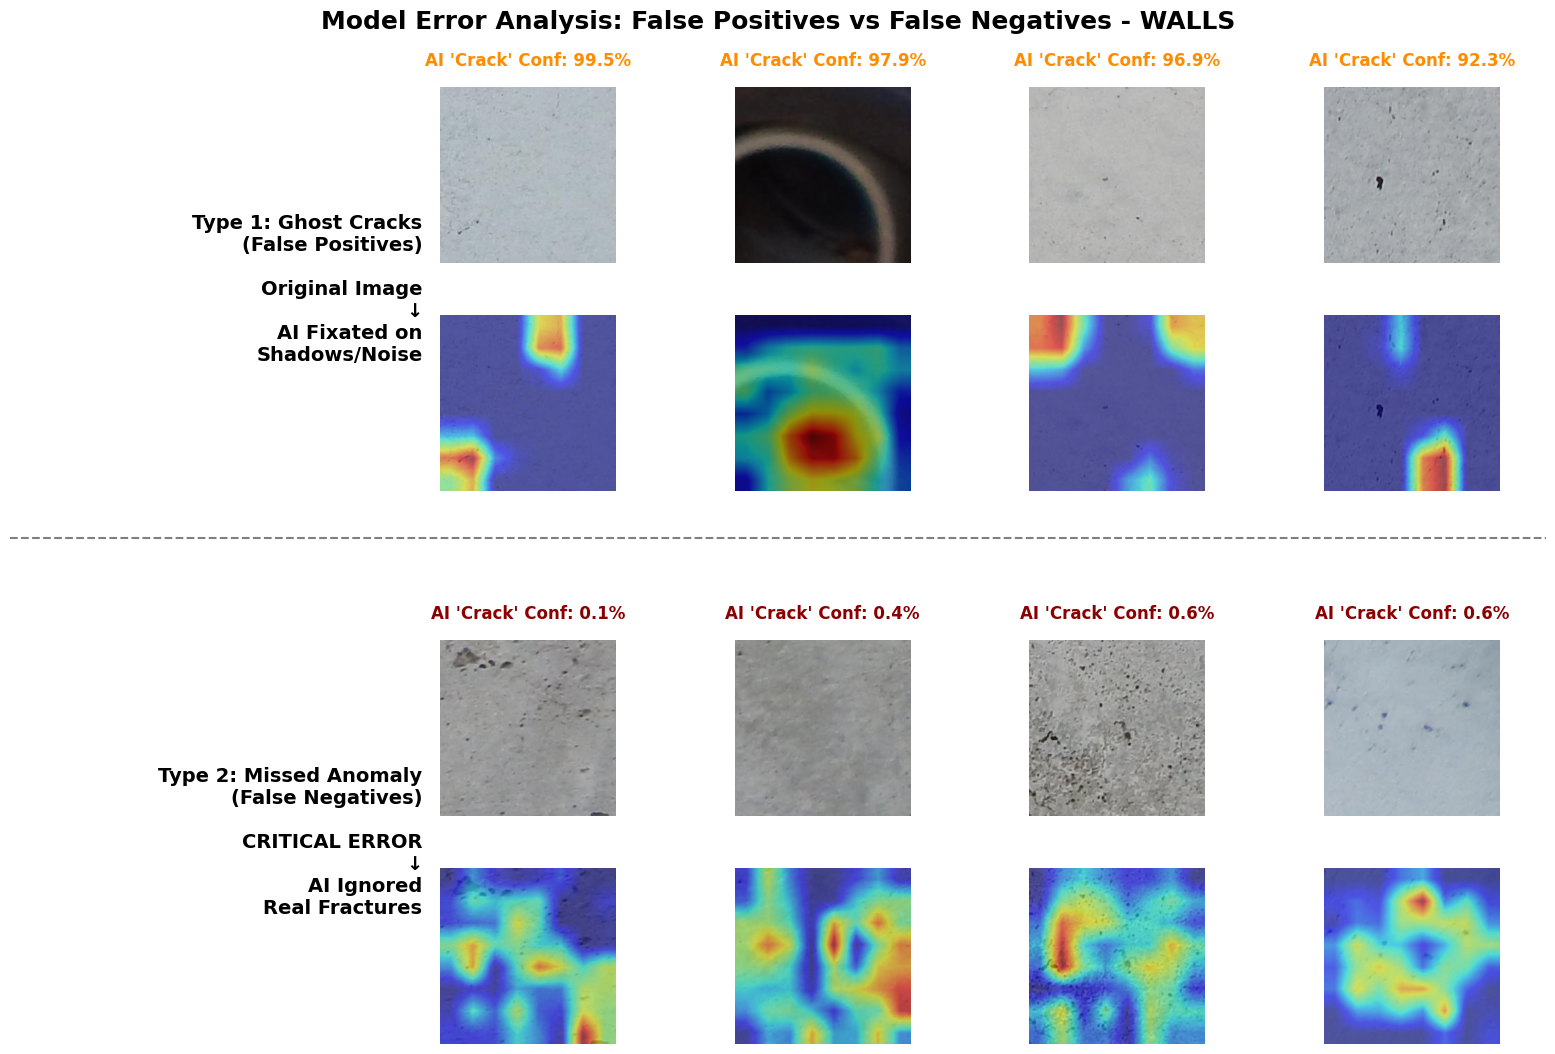

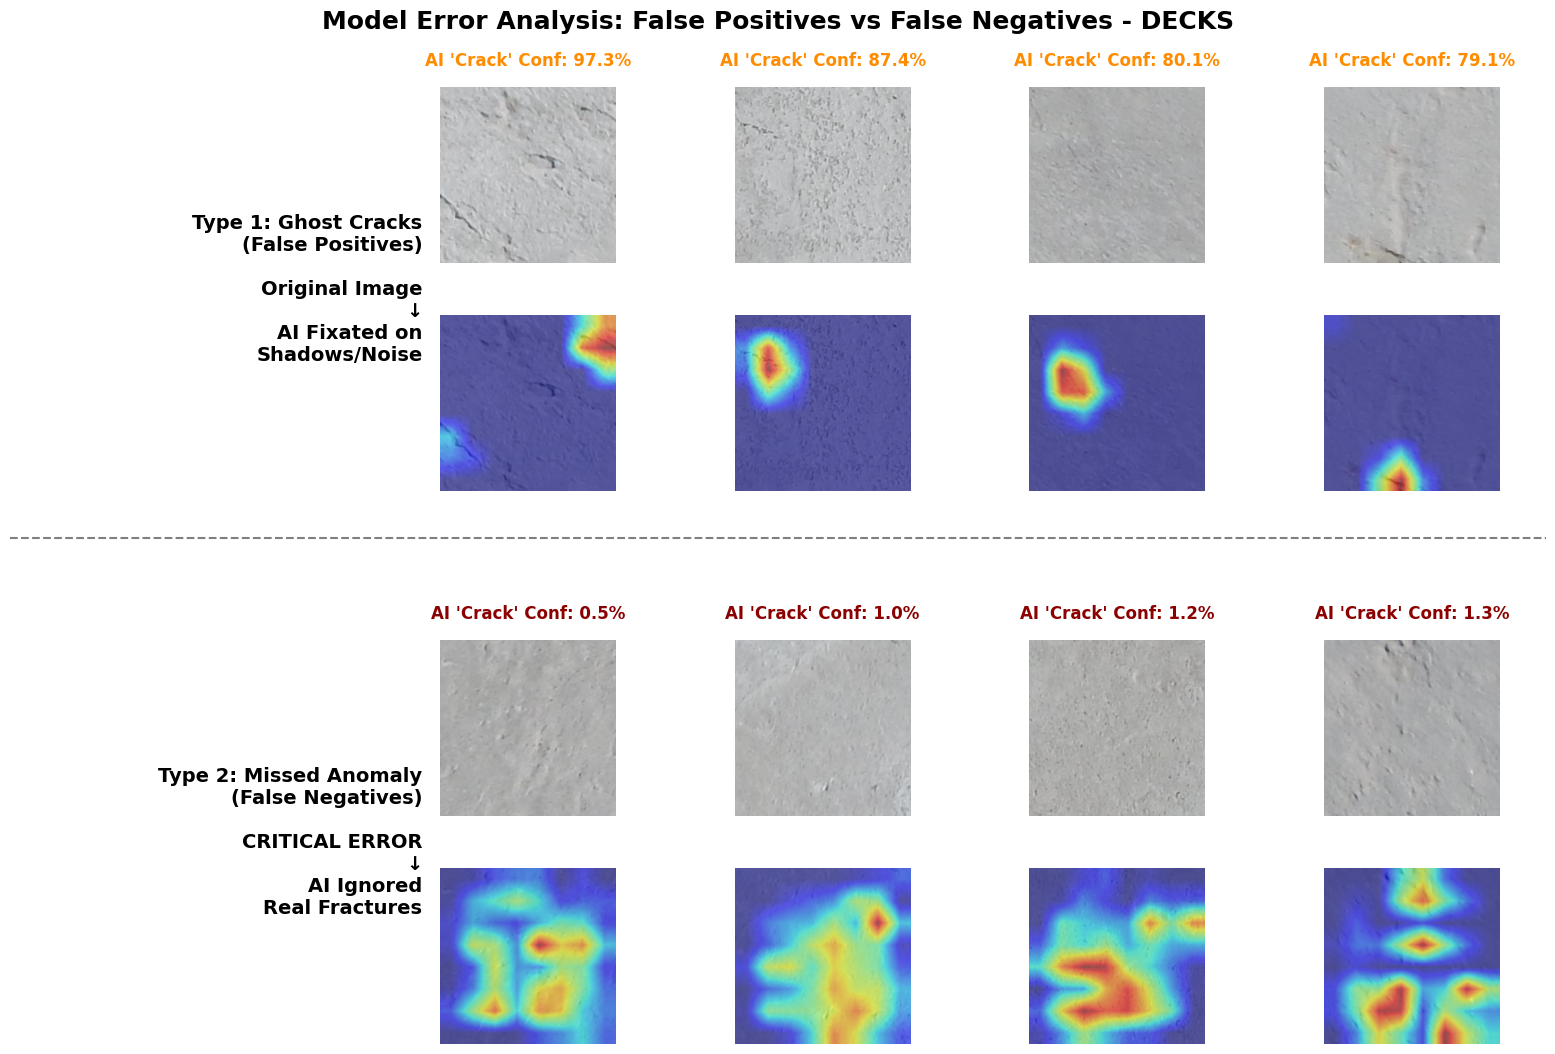

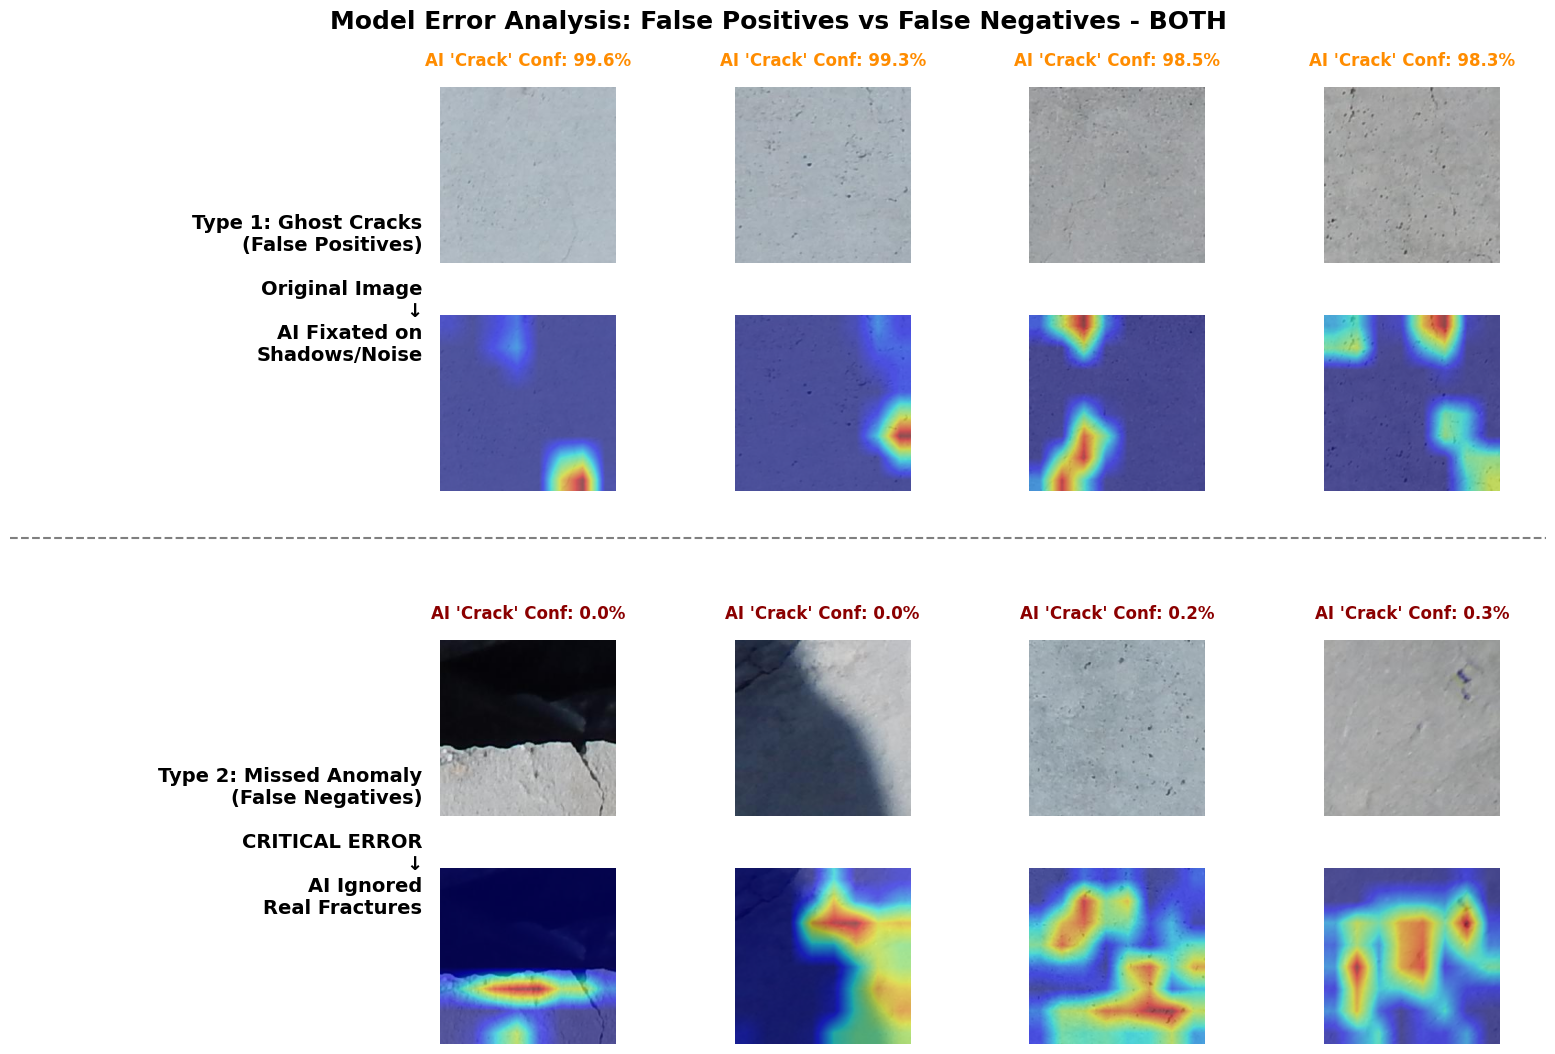

In [ ]:
# ==========================================
# Mode 3: Failure Case Deep Dive with Grad-CAM
# ==========================================
def run_explainability_failures(pretrained_model_path: str, test_dataloader, device: torch.device, domain_name: str, threshold: float = 0.5, num_samples: int = 4):
    
    eval_model = build_model("resnet50", freeze_early=True).to(device)
    eval_model.load_state_dict(torch.load(pretrained_model_path, map_location=device, weights_only=True))
    eval_model.eval()

    false_positives, false_negatives = [], []
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)

    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(device)
            logits = eval_model(images)
            probs = torch.sigmoid(logits).squeeze(1)
            preds = (probs >= threshold).long()  
            labels = labels.to(device)
            
            for i in range(len(labels)):
                target, pred, prob = labels[i].item(), preds[i].item(), probs[i].item()
                if target == 0 and pred == 1:
                    img_unnorm = (images[i] * std + mean).clamp(0, 1).cpu()  
                    false_positives.append((img_unnorm, images[i].cpu(), prob, pred))
                elif target == 1 and pred == 0:
                    img_unnorm = (images[i] * std + mean).clamp(0, 1).cpu()
                    false_negatives.append((img_unnorm, images[i].cpu(), prob, pred))
                    
    false_positives.sort(key=lambda x: x[2], reverse=True)  
    false_negatives.sort(key=lambda x: x[2], reverse=False) 

    top_fps = false_positives[:num_samples]
    top_fns = false_negatives[:num_samples]
    
    gradcam = GradCAM(eval_model, find_last_conv_layer(eval_model))

    def process_gradcam(cases_list):
        results = [] 
        for (img_unnorm, img_norm, prob, pred_idx) in cases_list:
            x = img_norm.unsqueeze(0).to(device)
            x.requires_grad = True
            cam = gradcam(x, class_idx=pred_idx)
            img_np = img_unnorm.permute(1, 2, 0).numpy()
            overlay = apply_heatmap_overlay(img_np, cam, alpha=0.55) 
            results.append((img_np, overlay, prob))
        return results

    try:
        fp_results = process_gradcam(top_fps)
        fn_results = process_gradcam(top_fns)
    finally:
        gradcam.close() 

    actual_fps = len(fp_results)
    actual_fns = len(fn_results)
    actual_samples = max(actual_fps, actual_fns)
    
    if actual_samples == 0:
        print(f" -> No Failures in {domain_name}. Perfect Model!")
        return

    fig, axes = plt.subplots(5, actual_samples, figsize=(4 * actual_samples, 11), 
                             gridspec_kw={'height_ratios': [1, 1, 0.25, 1, 1]})
    fig.suptitle(f"Model Error Analysis: False Positives vs False Negatives - {domain_name.upper()}", fontsize=18, fontweight='bold', y=0.97)

    if actual_samples == 1:
        axes = axes[:, np.newaxis] 

    for ax in axes[2, :]:
        ax.axis('off')

    def draw_block(results_list, start_row, title, text_color):
        for i in range(actual_samples):
            ax_orig = axes[start_row, i]
            ax_orig.axis('off')
            if i < len(results_list):
                img_np, overlay_np, prob = results_list[i]
                ax_orig.imshow(img_np)
                ax_orig.set_title(f"AI 'Crack' Conf: {prob*100:.1f}%", color=text_color, fontsize=12, fontweight='bold', pad=15)
                
            ax_heatmap = axes[start_row + 1, i]
            ax_heatmap.axis('off')
            if i < len(results_list):
                img_np, overlay_np, prob = results_list[i]
                ax_heatmap.imshow(overlay_np)
        
        axes[start_row, 0].text(-0.1, -0.15, title, transform=axes[start_row, 0].transAxes, 
                                fontsize=14, fontweight='bold', va='center', ha='right', rotation=0)

    draw_block(fp_results, start_row=0, title="Type 1: Ghost Cracks\n(False Positives)\n\nOriginal Image\n↓\nAI Fixated on\nShadows/Noise", text_color="darkorange")
    draw_block(fn_results, start_row=3, title="Type 2: Missed Anomaly\n(False Negatives)\n\nCRITICAL ERROR\n↓\nAI Ignored\nReal Fractures", text_color="darkred")

    plt.subplots_adjust(left=0.26, right=0.98, top=0.90, bottom=0.03, hspace=0.35, wspace=0.1) 

    line = plt.Line2D([0.02, 0.98], [0.49], transform=fig.transFigure, color="black", linestyle="--", linewidth=1.5, alpha=0.5)
    fig.add_artist(line)

    plt.show()

# -------------------------------------------------------------
for domain, configs in pipelines_artifacts.items():
    run_explainability_failures(
        pretrained_model_path=configs["model_path"],
        test_dataloader=configs["test_dl"],
        device=device,
        domain_name=domain,
        threshold=CRITICAL_THRESHOLD,  
        num_samples=4  
    )
